
Polynomial degree: 1

Fold 1
Test x: [-3.  -2.6 -2.2 -1.8]
True y: [4.8 1.9 3.7 0.4]
Predicted y: [-2.171 -1.75  -1.33  -0.909]
Train SSR: 36.481643
Test SSR:  88.931406

Fold 2
Test x: [-1.4 -1.  -0.6 -0.2]
True y: [ 2.8 -0.9  1.5 -1.8]
Predicted y: [2.305 2.373 2.442 2.511]
Train SSR: 46.019431
Test SSR:  30.435888

Fold 3
Test x: [0.2 0.6 1.  1.4]
True y: [ 0.9 -0.7  2.4  0.6]
Predicted y: [2.628 2.773 2.919 3.064]
Train SSR: 55.675117
Test SSR:  21.392685

Fold 4
Test x: [1.8 2.2 2.6 3. ]
True y: [4.1 2.3 6.  4.7]
Predicted y: [-0.55  -0.835 -1.119 -1.404]
Train SSR: 30.196154
Test SSR:  119.388698

Average across folds
Mean train SSR: 42.093086
Mean test SSR:  65.037169

Polynomial degree: 2

Fold 1
Test x: [-3.  -2.6 -2.2 -1.8]
True y: [4.8 1.9 3.7 0.4]
Predicted y: [5.688 4.303 3.118 2.134]
Train SSR: 23.048169
Test SSR:  9.906308

Fold 2
Test x: [-1.4 -1.  -0.6 -0.2]
True y: [ 2.8 -0.9  1.5 -1.8]
Predicted y: [0.958 0.572 0.351 0.294]
Train SSR: 17.545858
Test SSR:  11.266678


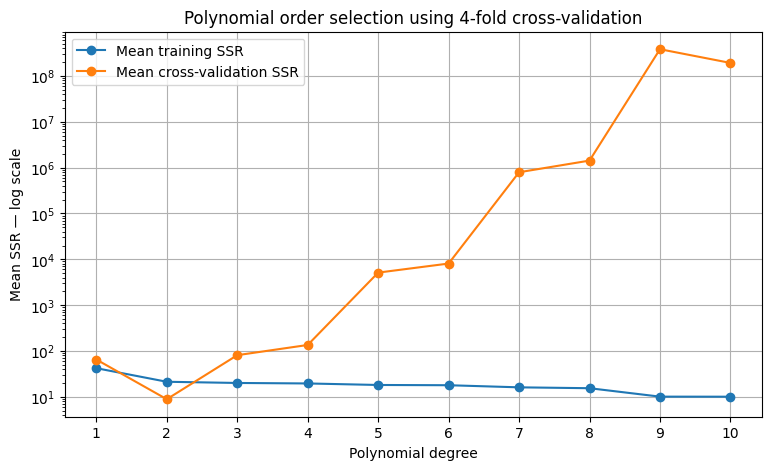


Best polynomial degree: 2
Best mean CV SSR: 8.851552


In [76]:
import numpy as np
import matplotlib.pyplot as plt

x_all = np.array([
    -3.0, -2.6, -2.2, -1.8, -1.4, -1.0, -0.6, -0.2,
     0.2,  0.6,  1.0,  1.4,  1.8,  2.2,  2.6,  3.0
])

y_all = np.array([
    4.8, 1.9, 3.7, 0.4, 2.8, -0.9, 1.5, -1.8,
    0.9, -0.7, 2.4, 0.6, 4.1, 2.3, 6.0, 4.7
])

# M is the number of polynomial coefficients.
# Polynomial degree = M - 1.
orders = [2,3,4,5,6,7,8,9,10,11]

number_of_folds = 4
lamb = 0

# Split the dataset indices into four consecutive folds.
fold_indices = np.array_split(
    np.arange(len(x_all)),
    number_of_folds
)

mean_train_ssr_per_order = []
mean_test_ssr_per_order = []

for M in orders:

    fold_train_ssr = []
    fold_test_ssr = []

    print("\n" + "=" * 50)
    print(f"Polynomial degree: {M - 1}")
    print("=" * 50)

    for fold_number in range(number_of_folds):

        # Current fold is the test set.
        test_indices = fold_indices[fold_number]

        # All remaining folds form the training set.
        train_indices = np.concatenate([
            fold_indices[i]
            for i in range(number_of_folds)
            if i != fold_number
        ])

        x_train = x_all[train_indices]
        y_train = y_all[train_indices]

        x_test = x_all[test_indices]
        y_test = y_all[test_indices]

        # Scale using only training data.
        x_mean = np.mean(x_train)
        x_scale = np.max(np.abs(x_train - x_mean))

        x_train_scaled = (x_train - x_mean) / x_scale
        x_test_scaled = (x_test - x_mean) / x_scale

        # Polynomial design matrices.
        phi_train = np.vander(
            x_train_scaled,
            N=M,
            increasing=True
        )

        phi_test = np.vander(
            x_test_scaled,
            N=M,
            increasing=True
        )

        # Ridge regularisation.
        regulariser = lamb * np.eye(M)

        # Do not regularise the intercept.
        regulariser[0, 0] = 0

        A = phi_train.T @ phi_train + regulariser
        b = phi_train.T @ y_train

        w = np.linalg.solve(A, b)

        # Predictions.
        y_train_pred = phi_train @ w
        y_test_pred = phi_test @ w

        # Sum of squared residuals.
        train_ssr = np.sum((y_train - y_train_pred) ** 2)
        test_ssr = np.sum((y_test - y_test_pred) ** 2)

        fold_train_ssr.append(train_ssr)
        fold_test_ssr.append(test_ssr)

        print(f"\nFold {fold_number + 1}")
        print("Test x:", x_test)
        print("True y:", y_test)
        print("Predicted y:", np.round(y_test_pred, 3))
        print(f"Train SSR: {train_ssr:.6f}")
        print(f"Test SSR:  {test_ssr:.6f}")

    # Average error across all folds for this polynomial order.
    mean_train_ssr = np.mean(fold_train_ssr)
    mean_test_ssr = np.mean(fold_test_ssr)

    mean_train_ssr_per_order.append(mean_train_ssr)
    mean_test_ssr_per_order.append(mean_test_ssr)

    print("\nAverage across folds")
    print(f"Mean train SSR: {mean_train_ssr:.6f}")
    print(f"Mean test SSR:  {mean_test_ssr:.6f}")


# Compare average CV error across polynomial orders.
degrees = np.array(orders) - 1

plt.figure(figsize=(9, 5))

plt.plot(
    degrees,
    mean_train_ssr_per_order,
    marker="o",
    label="Mean training SSR"
)

plt.plot(
    degrees,
    mean_test_ssr_per_order,
    marker="o",
    label="Mean cross-validation SSR"
)

plt.yscale("log")

plt.xlabel("Polynomial degree")
plt.ylabel("Mean SSR — log scale")
plt.title("Polynomial order selection using 4-fold cross-validation")
plt.xticks(degrees)
plt.grid()
plt.legend()
plt.show()


# Select the polynomial degree with the lowest mean validation error.
best_index = np.argmin(mean_test_ssr_per_order)

best_M = orders[best_index]
best_degree = best_M - 1
best_cv_ssr = mean_test_ssr_per_order[best_index]

print("\n" + "=" * 50)
print(f"Best polynomial degree: {best_degree}")
print(f"Best mean CV SSR: {best_cv_ssr:.6f}")
print("=" * 50)

Best degree: 2
Best lambda: 1.0
Best CV MSE: 2.8597651110081537


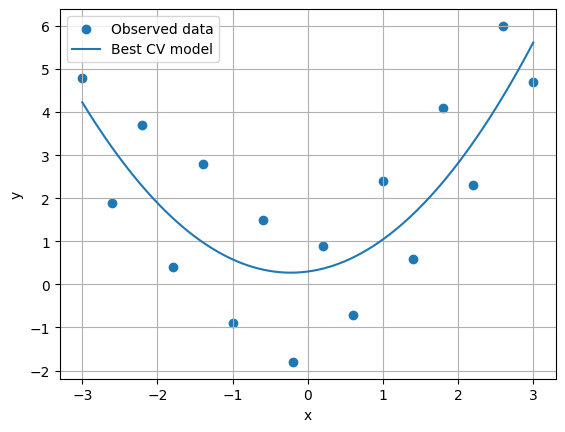

In [79]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV, KFold

x = np.array([
    -3.0, -2.6, -2.2, -1.8, -1.4, -1.0, -0.6, -0.2,
     0.2,  0.6,  1.0,  1.4,  1.8,  2.2,  2.6,  3.0
]).reshape(-1, 1)

y = np.array([
    4.8, 1.9, 3.7, 0.4, 2.8, -0.9, 1.5, -1.8,
    0.9, -0.7, 2.4, 0.6, 4.1, 2.3, 6.0, 4.7
])

model = Pipeline([
    ("polynomial", PolynomialFeatures(include_bias=True)),
    ("scaler", StandardScaler()),
    ("ridge", Ridge())
])

parameter_grid = {
    "polynomial__degree": range(1, 11),
    "ridge__alpha": [0.0, 1e-5, 1e-3, 0.01, 0.1, 1.0]
}

cv = KFold(
    n_splits=4,
    shuffle=True,
    random_state=42
)

search = GridSearchCV(
    estimator=model,
    param_grid=parameter_grid,
    scoring="neg_mean_squared_error",
    cv=cv,
    n_jobs=-1
)

search.fit(x, y)

print("Best degree:", search.best_params_["polynomial__degree"])
print("Best lambda:", search.best_params_["ridge__alpha"])
print("Best CV MSE:", -search.best_score_)

best_model = search.best_estimator_

x_axis = np.linspace(x.min(), x.max(), 1000).reshape(-1, 1)
y_axis = best_model.predict(x_axis)

plt.scatter(x[:, 0], y, label="Observed data")
plt.plot(x_axis[:, 0], y_axis, label="Best CV model")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid()
plt.show()

Best polynomial degree: 2
Best CV MSE: 3.0682351170165925


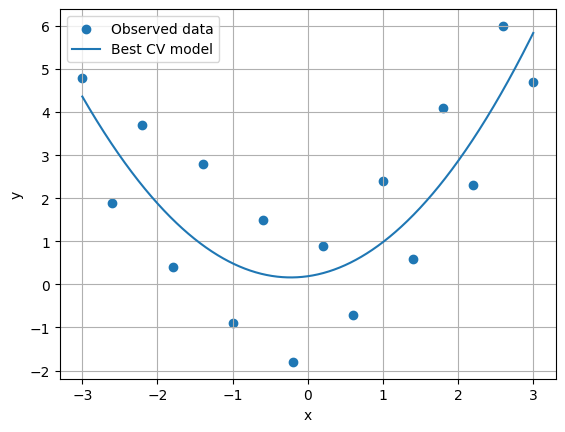

In [80]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GridSearchCV, KFold

x = np.array([
    -3.0, -2.6, -2.2, -1.8, -1.4, -1.0, -0.6, -0.2,
     0.2,  0.6,  1.0,  1.4,  1.8,  2.2,  2.6,  3.0
]).reshape(-1, 1)

y = np.array([
    4.8, 1.9, 3.7, 0.4, 2.8, -0.9, 1.5, -1.8,
    0.9, -0.7, 2.4, 0.6, 4.1, 2.3, 6.0, 4.7
])

model = Pipeline([
    ("polynomial", PolynomialFeatures(include_bias=True)),
    ("regression", LinearRegression())
])

parameter_grid = {
    "polynomial__degree": range(1, 11)
}

cv = KFold(
    n_splits=4,
    shuffle=True,
    random_state=42
)

search = GridSearchCV(
    estimator=model,
    param_grid=parameter_grid,
    scoring="neg_mean_squared_error",
    cv=cv
)

search.fit(x, y)

best_degree = search.best_params_["polynomial__degree"]
best_cv_mse = -search.best_score_

print("Best polynomial degree:", best_degree)
print("Best CV MSE:", best_cv_mse)

best_model = search.best_estimator_

x_axis = np.linspace(x.min(), x.max(), 1000).reshape(-1, 1)
y_axis = best_model.predict(x_axis)

plt.scatter(x[:, 0], y, label="Observed data")
plt.plot(x_axis[:, 0], y_axis, label="Best CV model")
plt.xlabel("x")
plt.ylabel("y")
plt.grid()
plt.legend()
plt.show()

In [82]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
import numpy as np
import matplotlib.pyplot as plt

x = np.array([
    [-2.5, -1.8],
    [-2.2, -0.9],
    [-1.8, -1.4],
    [-1.5, -0.3],
    [-1.2, -0.8],
    [-0.8,  0.2],
    [-0.5, -0.4],
    [-0.2,  0.7],
    [ 0.1, -0.3],
    [ 0.4,  0.8],
    [ 0.7,  0.2],
    [ 1.0,  1.1],
    [ 1.3,  0.5],
    [ 1.6,  1.4],
    [ 2.0,  0.9],
    [ 2.3,  1.8],
    [ 2.6,  1.1],
    [ 3.0,  2.0]
])

t = np.array([
    0, 0, 0, 0, 0, 0,
    0, 1, 0, 1, 1, 1,
    1, 1, 1, 1, 1, 1
])

model = Pipeline([
    ("polynomial", PolynomialFeatures(include_bias=False)),
    ("logistic regression", LogisticRegression(max_iter=10000))
])

parameter_grid = {
    "polynomial__degree": range(1, 11),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
search = GridSearchCV(estimator= model, param_grid=parameter_grid, cv=cv)

search.fit(x, t)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...iter=10000))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'polynomial__degree': range(1, 11)}"
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of infor

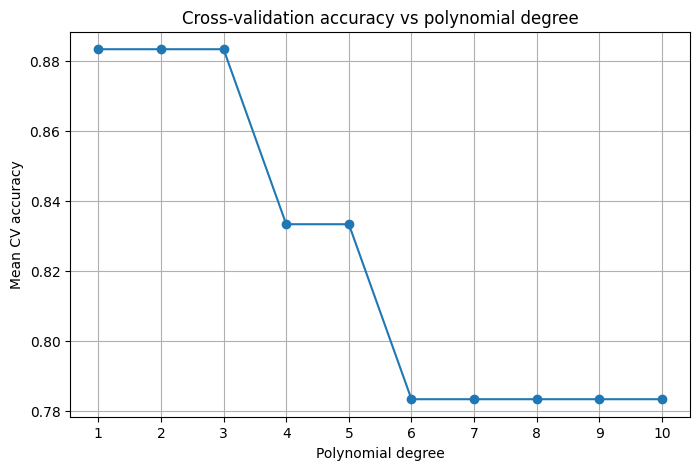

Best degree: 1
Best CV accuracy: 0.8833333333333332


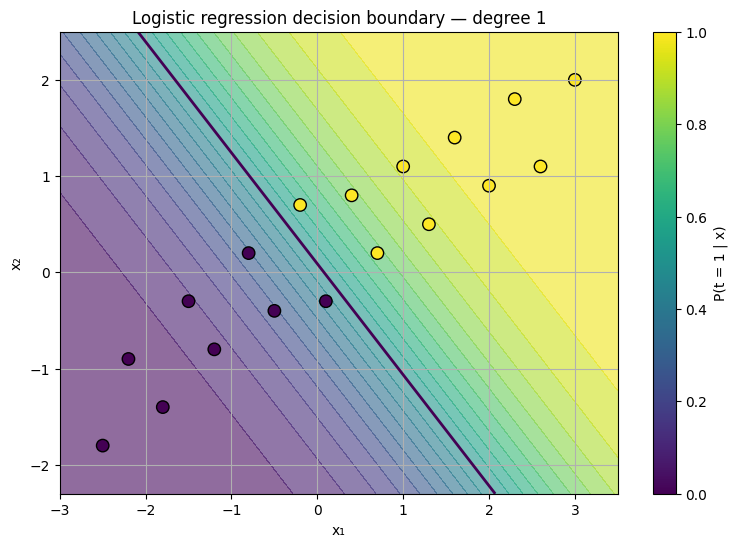

In [85]:
# -----------------------------
# 1. Plot CV score vs degree
# -----------------------------

degrees = search.cv_results_["param_polynomial__degree"].data
mean_cv_score = search.cv_results_["mean_test_score"]

plt.figure(figsize=(8, 5))
plt.plot(degrees, mean_cv_score, marker="o")

plt.xlabel("Polynomial degree")
plt.ylabel("Mean CV accuracy")
plt.title("Cross-validation accuracy vs polynomial degree")
plt.xticks(degrees)
plt.grid()
plt.show()

print("Best degree:", search.best_params_["polynomial__degree"])
print("Best CV accuracy:", search.best_score_)


# -----------------------------
# 2. Plot best decision boundary
# -----------------------------

best_model = search.best_estimator_

x1_min, x1_max = x[:, 0].min() - 0.5, x[:, 0].max() + 0.5
x2_min, x2_max = x[:, 1].min() - 0.5, x[:, 1].max() + 0.5

x1_grid, x2_grid = np.meshgrid(
    np.linspace(x1_min, x1_max, 400),
    np.linspace(x2_min, x2_max, 400)
)

grid_points = np.column_stack([
    x1_grid.ravel(),
    x2_grid.ravel()
])

# P(t = 1 | x)
probability = best_model.predict_proba(grid_points)[:, 1]
probability = probability.reshape(x1_grid.shape)

plt.figure(figsize=(9, 6))

# Probability surface
plt.contourf(
    x1_grid,
    x2_grid,
    probability,
    levels=np.linspace(0, 1, 21),
    alpha=0.6
)

# Decision boundary where P(t = 1 | x) = 0.5
plt.contour(
    x1_grid,
    x2_grid,
    probability,
    levels=[0.5],
    linewidths=2
)

# Original data
plt.scatter(
    x[:, 0],
    x[:, 1],
    c=t,
    edgecolors="black",
    s=80
)

plt.colorbar(label="P(t = 1 | x)")
plt.xlabel("x₁")
plt.ylabel("x₂")
plt.title(
    f"Logistic regression decision boundary — "
    f"degree {search.best_params_['polynomial__degree']}"
)
plt.grid()
plt.show()

In [87]:
x_new = np.array([
    [-1.0, -0.5],
    [ 0.5,  0.4],
    [ 2.0,  1.5]
])

t_pred = search.predict(x_new)
t_pred

array([0, 1, 1])

In [88]:
probabilities = search.predict_proba(x_new)

print(probabilities)

[[0.86863131 0.13136869]
 [0.27650721 0.72349279]
 [0.01747388 0.98252612]]


In [94]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

knn = Pipeline([
    ("scalar", StandardScaler()),
    ("knn", KNeighborsClassifier())
])

parameter_grid = {
    "knn__n_neighbors": range(1,10)
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
search = GridSearchCV(estimator=knn, cv=cv, param_grid=parameter_grid)

search.fit(x,t)
print(search.best_params_)

t_pred_knn = search.predict(x_new)
t_pred_knn

{'knn__n_neighbors': 3}


array([0, 1, 1])

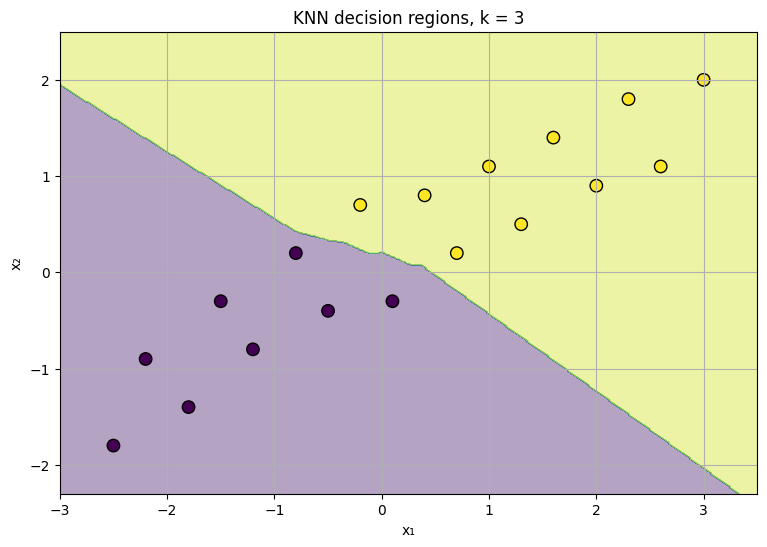

In [95]:
best_knn = search.best_estimator_

x1_min, x1_max = x[:, 0].min() - 0.5, x[:, 0].max() + 0.5
x2_min, x2_max = x[:, 1].min() - 0.5, x[:, 1].max() + 0.5

x1_grid, x2_grid = np.meshgrid(
    np.linspace(x1_min, x1_max, 400),
    np.linspace(x2_min, x2_max, 400)
)

grid_points = np.column_stack([
    x1_grid.ravel(),
    x2_grid.ravel()
])

grid_predictions = best_knn.predict(grid_points)
grid_predictions = grid_predictions.reshape(x1_grid.shape)

plt.figure(figsize=(9, 6))

plt.contourf(
    x1_grid,
    x2_grid,
    grid_predictions,
    alpha=0.4
)

plt.scatter(
    x[:, 0],
    x[:, 1],
    c=t,
    edgecolors="black",
    s=80
)

plt.xlabel("x₁")
plt.ylabel("x₂")
plt.title(
    f"KNN decision regions, k = "
    f"{search.best_params_['knn__n_neighbors']}"
)

plt.grid()
plt.show()

update finished after 100 iterations, and final weights are[64.50310498 29.57376791 20.1450806 ]


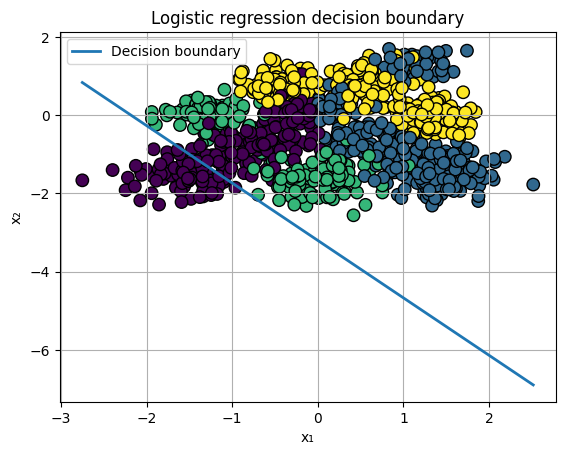

In [191]:
import numpy as np
import matplotlib.pyplot as plt

x = np.loadtxt("X.txt")
y = np.loadtxt("y_multiclass.txt")
x = np.asarray(x)

x1 = x[:, 0]
x2 = x[:, 1]

x_tilde = np.column_stack([
    np.ones(len(x)),
    x1,
    x2,
])

plt.scatter(
    x[:, 0],
    x[:, 1],
    c=y,
    edgecolors="black",
    s=80
)

def sigmoid(z):
    return 1/ (1 + np.exp(-z))

w = np.zeros(x_tilde.shape[1])
lr = 0.001

for iter in range(100):
    grad = x_tilde.T @ (y - sigmoid( x_tilde @ w))
    w_new = w + lr * grad
    if (np.linalg.norm(w_new - w) < 1e-3):
        w = w_new
        break
    w = w_new
    

print(f"update finished after {iter+1} iterations, and final weights are{w}")

x1_axis = np.linspace(
    x[:, 0].min(),
    x[:, 0].max(),
    500
)

if abs(w[2]) > 1e-12:
    x2_boundary = -(w[1] * x1_axis + w[0]) / w[2]

    plt.plot(
        x1_axis,
        x2_boundary,
        linewidth=2,
        label="Decision boundary"
    )
else:
    # Vertical boundary when the x2 coefficient is approximately zero
    x1_boundary = -w[0] / w[1]
    plt.axvline(
        x1_boundary,
        linewidth=2,
        label="Decision boundary"
    )

plt.xlabel("x₁")
plt.ylabel("x₂")
plt.title("Logistic regression decision boundary")
plt.legend()
plt.grid()
plt.show()

In [192]:
def rbf_kernel(x1, x2, gamma):
    diff = x1[:, None, :] - x2[None, :, :]
    squared_distance = np.sum(diff**2, axis=2)
    return np.exp(-gamma * squared_distance)

gamma = 1
K = rbf_kernel(x,x,gamma)

t_svm = np.where(y == 0, -1, 1)

Q = np.outer(t_svm,t_svm) @ K

def dual_objective(alpha, Q):
    return 0.5 * np.dot(alpha, Q @ alpha) - np.sum(alpha)

from scipy.optimize import minimize

C = 1.0
n = len(t_svm)

alpha0 = np.zeros(n)

bounds = [(0, C) for _ in range(n)]

constraint = {
    "type": "eq",
    "fun": lambda alpha: alpha @ t_svm
}

result = minimize(
    fun=dual_objective,
    x0=alpha0,
    args=(Q,),
    bounds=bounds,
    constraints=constraint,
    method="SLSQP"
)

alpha = result.x

print(result.success)
print(result.message)
print(alpha)



True
Optimization terminated successfully
[1.         0.28866008 0.28865856 0.28865684 0.28865893 1.
 0.2886631  0.28867493 1.         0.28865857 0.28865482 1.
 0.28865878 0.28866539 0.28866146 0.2886551  0.28866099 0.28865535
 1.         1.         0.28866244 1.         0.28866655 0.28866281
 0.2886551  0.28865473 0.28865338 0.28865689 0.28866014 0.28866387
 0.28865664 0.28866465 1.         0.28866318 1.         1.
 0.28866284 0.288663   0.28865577 0.28864985 0.28865707 0.28865937
 0.28866541 0.28865549 0.28866594 0.28866072 0.28866379 1.
 1.         0.28866044 0.28865666 0.2886527  0.2886727  0.28865401
 0.28866215 0.28867181 0.28865789 0.28865805 0.28866814 0.288665
 0.2886535  0.28866929 1.         0.28866276 0.28866132 0.28866477
 0.28864926 0.28865315 0.28866178 0.28864968 0.28864913 0.28866865
 1.         0.28865241 0.28866253 0.28866465 1.         0.28866339
 0.28865219 1.         0.28865568 0.2886676  0.28865407 0.28867586
 0.28865621 0.28865556 1.         1.         0.2886583

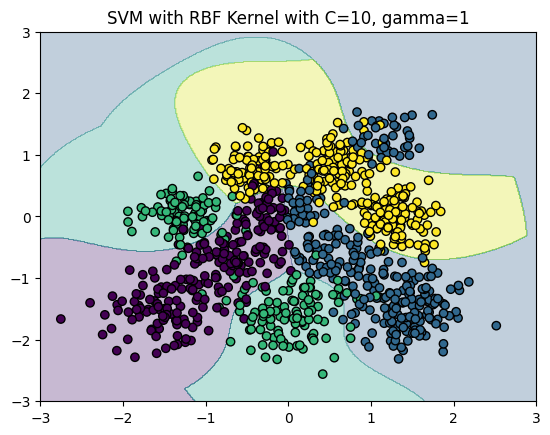

In [193]:
from sklearn import datasets
from sklearn.svm import SVC
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler

model = Pipeline([
    ("scalar", StandardScaler()),
    ("rbf_svc", SVC(kernel='rbf'))
])

parameter_grid = {
    "rbf_svc__C": [0.01,0.1,1,10,100],
    "rbf_svc__gamma": [0.01, 0.1, 1, 10, 100]
}
cv = StratifiedKFold(n_splits=10, shuffle=False)

search = GridSearchCV(
    param_grid=parameter_grid, 
    cv=cv, 
    estimator=model,
    scoring="accuracy",
    n_jobs=-1
    )

t = np.where(y == 0, -1, 1)
search.fit(x, y)

# pick best C and gamma from search best params solutions:
best_C = search.best_params_['rbf_svc__C']
best_gamma = search.best_params_['rbf_svc__gamma']

# Train SVM with RBF kernel
clf = SVC(kernel='rbf', C=best_C, gamma=best_gamma)
clf.fit(x, y)

# Plot decision boundary
import numpy as np
xx, yy = np.meshgrid(np.linspace(-3, 3, 500),
np.linspace(-3.0, 3, 500))
Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(x[:, 0], x[:, 1], c=y, edgecolors='k')
plt.title(f"SVM with RBF Kernel with C={best_C}, gamma={best_gamma}")
plt.show()

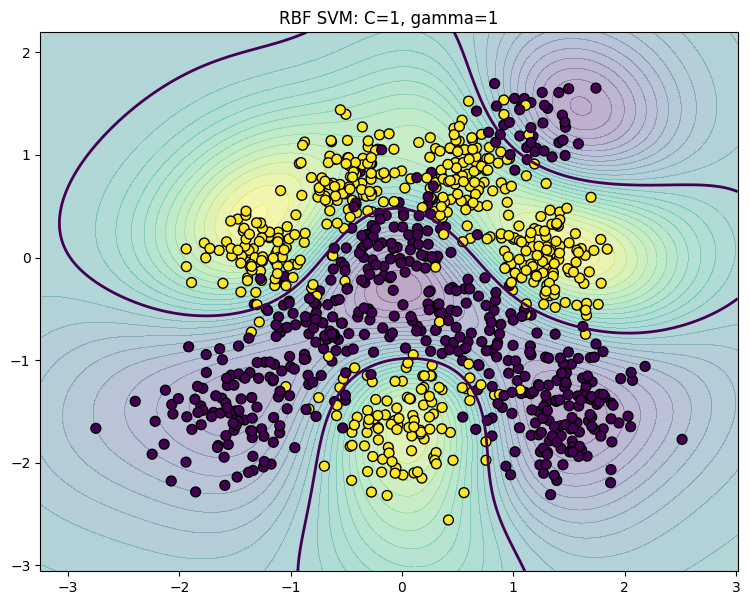

Training accuracy: 0.461
Best CV accuracy: 0.923


In [187]:
scores = search.decision_function(grid_points).reshape(xx.shape)

plt.figure(figsize=(9, 7))

plt.contourf(
    xx,
    yy,
    scores,
    levels=30,
    alpha=0.35
)

plt.contour(
    xx,
    yy,
    scores,
    levels=[0],
    linewidths=2
)

plt.scatter(
    x[:, 0],
    x[:, 1],
    c=y,
    edgecolors="black",
    s=50
)

plt.title(
    f"RBF SVM: C={search.best_params_['rbf_svc__C']}, "
    f"gamma={search.best_params_['rbf_svc__gamma']}"
)

plt.show()
print("Training accuracy:", search.score(x, y))
print("Best CV accuracy:", search.best_score_)